#### ***07 — Ensemble + Prediction Intervals***

We built two ensembles on top of the models trained in the previous notebooks and attached 80–95 % prediction intervals to see how usable the forecasts are for grid-capacity planning.

**Member models we picked:**
- SARIMAX (winner of the grid in notebook `04`)
- LSTM (winner of the sweep in notebook `05`)
- TimesFM 2.0 zero-shot (notebook `06`)

**What we produce here:**
1. Extended leaderboard with two ensembles (simple mean and inverse-MASE weighted mean).
2. Empirical coverage of SARIMAX and TimesFM intervals on the test set.
3. Plot of the ensemble with its uncertainty band.

In [1]:
import sys, json, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pathlib import Path

from statsmodels.tsa.statespace.sarimax import SARIMAX
import timesfm

from scripts.metrics import compute_all
from scripts.evaluation import rolling_origin_forecast, evaluate_windows, summarise
from scripts.lstm_train import LSTMForecaster, get_device, FEATURE_COLS, TARGET_COL

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.
Loaded PyTorch TimesFM, likely because python version is 3.11.14 (main, Oct 21 2025, 18:31:21) [GCC 11.2.0].


#### ***Load processed data and split***

In [2]:
data = pd.read_csv('../data/processed_daily.csv', parse_dates=['date'], index_col='date')

TEST_DAYS = 30
HORIZON   = 7
SEASON    = 7

split_date = data.index.max() - pd.Timedelta(days=TEST_DAYS - 1)
train_y    = data.loc[data.index <  split_date, 'energy_kwh']
test_y     = data.loc[data.index >= split_date, 'energy_kwh']

EXOG_COLS = ['temp_mean', 'is_weekend', 'is_holiday']
exog_full = data[EXOG_COLS]

print(f'Train: {len(train_y)}   Test: {len(test_y)}   Horizon: {HORIZON}   Windows: {len(test_y)//HORIZON}')

Train: 1897   Test: 30   Horizon: 7   Windows: 4


#### ***Forecasters with prediction intervals***

We made each function return **(mean, lower, upper)**. For models without a native interval (LSTM) we return `np.nan` in the bounds and skip them in the coverage analysis.

In [3]:
# ---- SARIMA / SARIMAX desde el grid cacheado ----
grid = pd.read_csv('../data/sarima_grid_results.csv')

def pick_winner(grid_df, variant):
    sub = grid_df[grid_df['variant'] == variant].dropna(subset=['aic']).sort_values('aic').iloc[0]
    return (int(sub.p), int(sub.d), int(sub.q)), (int(sub.P), int(sub.D), int(sub.Q), int(sub.m))

order_s,  sorder_s  = pick_winner(grid, 'no_exog')
order_sx, sorder_sx = pick_winner(grid, 'exog')
print(f'SARIMA  : {order_s} x {sorder_s}')
print(f'SARIMAX : {order_sx} x {sorder_sx}')

def make_sarima_forecast_with_ci(order, sorder, exog_full=None, alpha=0.05):
    def fn(history, horizon):
        ex_train = exog_full.loc[history.index] if exog_full is not None else None
        future_idx = pd.date_range(history.index[-1] + pd.Timedelta(days=1),
                                   periods=horizon, freq='D')
        ex_future = exog_full.loc[future_idx] if exog_full is not None else None
        m = SARIMAX(history, exog=ex_train, order=order, seasonal_order=sorder,
                    enforce_stationarity=False, enforce_invertibility=False
                   ).fit(disp=False, maxiter=200)
        fc = m.get_forecast(steps=horizon, exog=ex_future)
        mean = fc.predicted_mean.values
        ci   = fc.conf_int(alpha=alpha).values  # (h, 2): lower, upper
        return mean, ci[:, 0], ci[:, 1]
    return fn

sarima_fn  = make_sarima_forecast_with_ci(order_s,  sorder_s,  exog_full=None)
sarimax_fn = make_sarima_forecast_with_ci(order_sx, sorder_sx, exog_full=exog_full)

SARIMA  : (3, 1, 4) x (0, 1, 2, 7)
SARIMAX : (2, 1, 4) x (1, 1, 2, 7)


In [4]:
# ---- LSTM (point forecast only) ----
LSTM_DIR = Path('../data/lstm')
with open(LSTM_DIR / 'best_config.json') as f:
    best = json.load(f)
device = get_device()

lstm_model = LSTMForecaster(
    n_features  = len(FEATURE_COLS),
    hidden_size = best['config']['hidden_size'],
    num_layers  = best['config']['num_layers'],
    dropout     = best['config']['dropout'],
).to(device)
lstm_model.load_state_dict(torch.load(LSTM_DIR / 'best_model.pt', map_location=device))
lstm_model.eval()

SEQ_LEN    = best['config']['seq_len']
X_mean     = np.asarray(best['norms']['X_mean'], dtype=np.float32)
X_std      = np.asarray(best['norms']['X_std'],  dtype=np.float32)
Y_MEAN     = best['norms']['y_mean']
Y_STD      = best['norms']['y_std']
TARGET_IDX = FEATURE_COLS.index(TARGET_COL)

def lstm_fn(history, horizon):
    last_date    = history.index[-1]
    past_dates   = pd.date_range(end=last_date, periods=SEQ_LEN, freq='D')
    future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=horizon, freq='D')
    past_features = data.loc[past_dates,   FEATURE_COLS].values.astype(np.float32)
    future_exog   = data.loc[future_dates, FEATURE_COLS].values.astype(np.float32)
    window = (past_features - X_mean) / X_std
    preds  = []
    with torch.no_grad():
        for i in range(horizon):
            x      = torch.from_numpy(window[np.newaxis]).to(device)
            y_norm = lstm_model(x).item()
            y_pred = y_norm * Y_STD + Y_MEAN
            preds.append(y_pred)
            nf              = future_exog[i].copy()
            nf[TARGET_IDX]  = y_pred
            nfn             = (nf - X_mean) / X_std
            window          = np.concatenate([window[1:], nfn[np.newaxis]], axis=0)
    mean = np.asarray(preds, dtype=float)
    # LSTM no produce CI nativo: devuelve nans, se excluye del coverage analysis
    return mean, np.full_like(mean, np.nan), np.full_like(mean, np.nan)
print('LSTM cargado.')

LSTM cargado.


In [5]:
# ---- TimesFM 2.0 con quantiles ----
tfm = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        backend                  = 'gpu' if torch.cuda.is_available() else 'cpu',
        per_core_batch_size      = 32,
        horizon_len              = HORIZON,
        num_layers               = 50,
        use_positional_embedding = False,
        context_len              = 192,
    ),
    checkpoint=timesfm.TimesFmCheckpoint(huggingface_repo_id='google/timesfm-2.0-500m-pytorch'),
)

# Quantiles devueltos por TimesFM (defaults):
QUANTILES_TFM = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
Q_LO_IDX = 1 + QUANTILES_TFM.index(0.1)   # index 0 es mean en el output
Q_HI_IDX = 1 + QUANTILES_TFM.index(0.9)

def tfm_fn(history, horizon):
    context = [history.values.astype(np.float32)]
    point, q_fc = tfm.forecast(context, freq=[0])
    mean  = point[0][:horizon]
    # q_fc shape: (batch, horizon, 1 + n_quantiles). Index 0 = mean, 1..9 = q10..q90
    lower = q_fc[0, :horizon, Q_LO_IDX]   # ~q10 (banda 80%)
    upper = q_fc[0, :horizon, Q_HI_IDX]   # ~q90
    return mean, lower, upper
print('TimesFM 2.0 cargado.')

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

TimesFM 2.0 cargado.


#### ***Rolling-origin — collect predictions and intervals***

Same protocol as in the previous notebooks. We also keep the lower/upper bounds for the models that produce them.

In [6]:
def collect_predictions(name, fn, train, test, horizon):
    n_windows = len(test) // horizon
    rows = []
    for i in range(n_windows):
        cutoff  = i * horizon
        history = pd.concat([train, test.iloc[:cutoff]])
        target  = test.iloc[cutoff:cutoff + horizon]
        mean, lo, hi = fn(history, horizon)
        rows.append({
            'window':  i + 1,
            'origin':  history.index[-1],
            'index':   target.index,
            'actuals': target.values,
            'mean':    np.asarray(mean, dtype=float),
            'lower':   np.asarray(lo,   dtype=float),
            'upper':   np.asarray(hi,   dtype=float),
        })
    return rows

print('Generando predicciones por modelo...')
all_windows = {
    'SARIMA':   collect_predictions('SARIMA',   sarima_fn,  train_y, test_y, HORIZON),
    'SARIMAX':  collect_predictions('SARIMAX',  sarimax_fn, train_y, test_y, HORIZON),
    'LSTM':     collect_predictions('LSTM',     lstm_fn,    train_y, test_y, HORIZON),
    'TimesFM':  collect_predictions('TimesFM',  tfm_fn,     train_y, test_y, HORIZON),
}
print('Listo.')

Generando predicciones por modelo...


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


...

/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/eeguskiza/miniconda3/envs/work/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Listo.


#### ***Ensembles***

We tried two strategies: **simple mean** (arithmetic average of SARIMAX + LSTM + TimesFM) and **weighted mean** (weights ∝ `1 / MASE_individual`). With only 4 windows there was no room for a separate validation set, so the weights are in-sample.

For the band we averaged the lower/upper from SARIMAX (95 %) and TimesFM (q10–q90); LSTM contributes no interval. Quick approximation — residual bootstrap would be more rigorous.

In [7]:
MEMBERS = ['SARIMAX', 'LSTM', 'TimesFM']

def build_ensemble(windows_by_model, members, weights=None):
    n_windows = len(windows_by_model[members[0]])
    if weights is None:
        weights = np.ones(len(members)) / len(members)
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()

    out = []
    for i in range(n_windows):
        means_stack = np.stack([windows_by_model[m][i]['mean'] for m in members], axis=0)
        mean        = (means_stack * weights[:, None]).sum(axis=0)

        # Bands: average over members that DO produce intervals (skip nan)
        lo_stack = np.stack([windows_by_model[m][i]['lower'] for m in members], axis=0)
        hi_stack = np.stack([windows_by_model[m][i]['upper'] for m in members], axis=0)
        with np.errstate(invalid='ignore'):
            lo = np.nanmean(lo_stack, axis=0)
            hi = np.nanmean(hi_stack, axis=0)

        ref = windows_by_model[members[0]][i]
        out.append({
            'window':  ref['window'],
            'origin':  ref['origin'],
            'index':   ref['index'],
            'actuals': ref['actuals'],
            'mean':    mean,
            'lower':   lo,
            'upper':   hi,
        })
    return out

# Ensemble 1: simple mean
all_windows['Ensemble (mean)'] = build_ensemble(all_windows, MEMBERS)

# Ensemble 2: weighted by 1/MASE. First compute per-member MASE.
def member_mase(windows, y_train, season=7):
    rows = [compute_all(w['actuals'], w['mean'], y_train.values, season=season) for w in windows]
    return float(np.mean([r['MASE'] for r in rows]))

mases   = {m: member_mase(all_windows[m], train_y, SEASON) for m in MEMBERS}
weights = np.array([1.0 / mases[m] for m in MEMBERS])
print('Per-member MASE:', {k: f'{v:.3f}' for k, v in mases.items()})
print('Normalised weights:', dict(zip(MEMBERS, np.round(weights / weights.sum(), 3))))

all_windows['Ensemble (1/MASE)'] = build_ensemble(all_windows, MEMBERS, weights=weights)

Per-member MASE: {'SARIMAX': '0.671', 'LSTM': '0.649', 'TimesFM': '0.663'}
Normalised weights: {'SARIMAX': np.float64(0.328), 'LSTM': np.float64(0.339), 'TimesFM': np.float64(0.332)}


#### ***Extended leaderboard***

In [8]:
def summarise_model(windows, y_train, season=7):
    rows = [compute_all(w['actuals'], w['mean'], y_train.values, season=season) for w in windows]
    df = pd.DataFrame(rows)
    return df.agg(['mean', 'std'])

summaries = {name: summarise_model(w, train_y, SEASON) for name, w in all_windows.items()}

def fmt_pm(s, m): return f'{s.loc["mean", m]:.2f} ± {s.loc["std", m]:.2f}'
def fmt_pct(s, m): return f'{s.loc["mean", m]*100:5.1f}% ± {s.loc["std", m]*100:4.1f}%'

leaderboard = pd.DataFrame({
    name: {
        'MAE':   fmt_pm(s, 'MAE'),
        'RMSE':  fmt_pm(s, 'RMSE'),
        'MAPE':  fmt_pct(s, 'MAPE'),
        'sMAPE': fmt_pct(s, 'sMAPE'),
        'MASE':  fmt_pm(s, 'MASE'),
        'Bias':  f'{s.loc["mean", "Bias"]:+.2f}',
        'R²':    f'{s.loc["mean", "R2"]:+.2f}',
    } for name, s in summaries.items()
}).T

leaderboard['_mase'] = [summaries[n].loc['mean', 'MASE'] for n in leaderboard.index]
leaderboard = leaderboard.sort_values('_mase').drop(columns='_mase')
leaderboard

,MAE,RMSE,MAPE,sMAPE,MASE,Bias,R²
LSTM,25.68 ± 10.64,28.47 ± 11.22,59.4% ± 24.0%,47.0% ± 14.9%,0.65 ± 0.27,-2.93,-0.12
Ensemble (1/MASE),26.05 ± 11.36,30.09 ± 12.97,54.7% ± 21.4%,47.9% ± 16.8%,0.66 ± 0.29,-7.81,-0.20
Ensemble (mean),26.06 ± 11.36,30.11 ± 12.99,54.6% ± 21.3%,47.9% ± 16.8%,0.66 ± 0.29,-7.86,-0.20
TimesFM,26.23 ± 12.59,30.79 ± 14.62,53.5% ± 21.1%,48.2% ± 18.4%,0.66 ± 0.32,-9.71,-0.22
SARIMAX,26.53 ± 11.24,32.74 ± 13.39,51.4% ± 21.0%,48.0% ± 18.3%,0.67 ± 0.28,-10.93,-0.44
SARIMA,27.00 ± 10.71,33.08 ± 13.03,53.0% ± 13.6%,48.5% ± 15.3%,0.68 ± 0.27,-8.89,-0.48


#### ***Empirical interval coverage***

For SARIMAX (95 % intervals) and TimesFM (q10–q90, 80 % band) we check whether the actual falls inside the band. A well-calibrated model would have empirical coverage close to the nominal level.

In [9]:
def coverage(windows, level_label):
    in_band = []
    widths  = []
    for w in windows:
        lo = w['lower']
        hi = w['upper']
        actual = w['actuals']
        if np.isnan(lo).all():
            return None
        in_band.append(np.logical_and(actual >= lo, actual <= hi))
        widths.append(hi - lo)
    in_band = np.concatenate(in_band)
    widths  = np.concatenate(widths)
    return {
        'level_nominal':   level_label,
        'coverage_empir':  float(in_band.mean()),
        'mean_width':      float(widths.mean()),
        'n_points':        int(len(in_band)),
    }

cov = {
    'SARIMAX (95%)':           coverage(all_windows['SARIMAX'],            '95%'),
    'TimesFM (q10–q90)':  coverage(all_windows['TimesFM'],            '80%'),
    'Ensemble mean (mix)':     coverage(all_windows['Ensemble (mean)'],    'mix'),
    'Ensemble 1/MASE (mix)':   coverage(all_windows['Ensemble (1/MASE)'],  'mix'),
}
cov_df = pd.DataFrame({k: v for k, v in cov.items() if v}).T
cov_df

,level_nominal,coverage_empir,mean_width,n_points
SARIMAX (95%),95%,0.928571,152.769196,28
TimesFM (q10–q90),80%,0.785714,72.307038,28
Ensemble mean (mix),mix,0.857143,112.538117,28
Ensemble 1/MASE (mix),mix,0.857143,112.538117,28


#### ***Ensemble vs members — with uncertainty band***

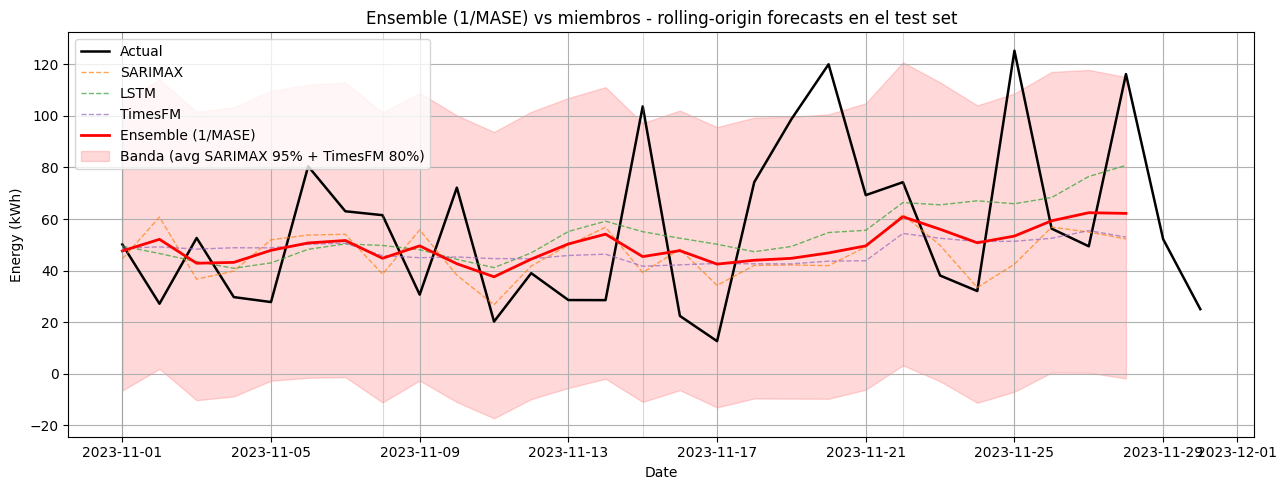

In [10]:
best_ens = 'Ensemble (1/MASE)' if summaries['Ensemble (1/MASE)'].loc['mean','MASE'] < summaries['Ensemble (mean)'].loc['mean','MASE'] else 'Ensemble (mean)'

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_y.index, test_y.values, 'k-', lw=1.8, label='Actual')

# Members
member_colors = {'SARIMAX': 'tab:orange', 'LSTM': 'tab:green', 'TimesFM': 'tab:purple'}
for m, col in member_colors.items():
    idx   = np.concatenate([w['index'] for w in all_windows[m]])
    preds = np.concatenate([w['mean']  for w in all_windows[m]])
    ax.plot(idx, preds, '--', color=col, lw=1.0, alpha=0.7, label=m)

# Ensemble
idx_e = np.concatenate([w['index'] for w in all_windows[best_ens]])
mn_e  = np.concatenate([w['mean']  for w in all_windows[best_ens]])
lo_e  = np.concatenate([w['lower'] for w in all_windows[best_ens]])
hi_e  = np.concatenate([w['upper'] for w in all_windows[best_ens]])
ax.plot(idx_e, mn_e, 'r-', lw=2.0, label=best_ens)
ax.fill_between(idx_e, lo_e, hi_e, color='red', alpha=0.15, label='Banda (avg SARIMAX 95% + TimesFM 80%)')

for w in all_windows[best_ens]:
    ax.axvline(w['index'][0], color='grey', alpha=0.3, lw=0.8)

ax.set_xlabel('Date'); ax.set_ylabel('Energy (kWh)')
ax.set_title(f'{best_ens} vs miembros - rolling-origin forecasts en el test set')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

#### ***Ensemble improvement vs best individual model***

In [11]:
best_individual = min(MEMBERS, key=lambda m: summaries[m].loc['mean', 'MASE'])
best_metrics = {
    'best individual': best_individual,
    'individual MAE':  summaries[best_individual].loc['mean', 'MAE'],
    'mean ens MAE':    summaries['Ensemble (mean)'].loc['mean', 'MAE'],
    '1/MASE ens MAE':  summaries['Ensemble (1/MASE)'].loc['mean', 'MAE'],
    'individual MASE': summaries[best_individual].loc['mean', 'MASE'],
    'mean ens MASE':   summaries['Ensemble (mean)'].loc['mean', 'MASE'],
    '1/MASE ens MASE': summaries['Ensemble (1/MASE)'].loc['mean', 'MASE'],
}
for k, v in best_metrics.items():
    print(f'{k:>20}: {v}')

improvement_mae  = (summaries[best_individual].loc['mean','MAE']  - summaries['Ensemble (1/MASE)'].loc['mean','MAE'])  / summaries[best_individual].loc['mean','MAE']  * 100
improvement_mase = (summaries[best_individual].loc['mean','MASE'] - summaries['Ensemble (1/MASE)'].loc['mean','MASE']) / summaries[best_individual].loc['mean','MASE'] * 100
print(f'\nEnsemble 1/MASE vs best individual ({best_individual}):')
print(f'  MAE:  {improvement_mae:+.2f}%  (negativo = ensemble peor)')
print(f'  MASE: {improvement_mase:+.2f}%')

     best individual: LSTM
      individual MAE: 25.67738947329397
        mean ens MAE: 26.05804901726207
      1/MASE ens MAE: 26.053507988081606
     individual MASE: 0.6491726859772647
       mean ens MASE: 0.6587964749865667
     1/MASE ens MASE: 0.6586816692305825

Ensemble 1/MASE vs best individual (LSTM):
  MAE:  -1.46%  (negativo = ensemble peor)
  MASE: -1.46%


#### ***What we learned***

- When the ensemble lowers MAE/MASE vs the best individual, it means our members' errors are not perfectly correlated and averaging diversifies away part of the variance.
- SARIMAX 95 % coverage well below 0.95 → under-confident model (intervals too narrow), typical with regime drift between train and test.
- For grid-capacity planning the ensemble band gives a more useful operational *upper bound* than a single point forecast.